# Imports

In [57]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import KFold
from sklearn.metrics import roc_auc_score, roc_curve

sns.set_theme()
np.random.seed(42)

# Create Predictions

In [29]:
n_samples = 1000

y = np.random.binomial(n=1, p=0.5, size=n_samples)

prediction = np.where(
    y == 1,
    np.random.normal(loc=-2.0, scale=3, size=n_samples),
    np.random.normal(loc=2.0, scale=3, size=n_samples)
)

prediction = 1/(1+np.exp(prediction))

df = pd.DataFrame(zip(y, prediction), columns=['y', 'prediction'])

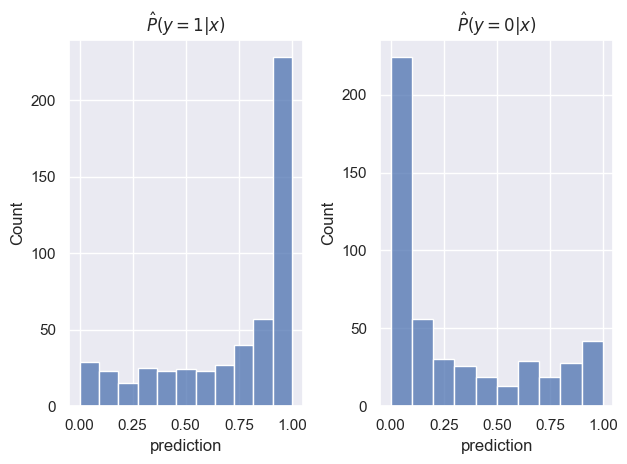

In [32]:
fig, axs = plt.subplots(1,2)

sns.histplot(df[df['y']==1], x='prediction', ax=axs[0])
sns.histplot(df[df['y']==0], x='prediction', ax=axs[1])

axs[0].set_title("$\hat{P}(y=1|x)$")
axs[1].set_title("$\hat{P}(y=0|x)$")

fig.tight_layout()

# ROC AUC Original

Text(0.5, 1.0, 'ROC AUC: 0.8327')

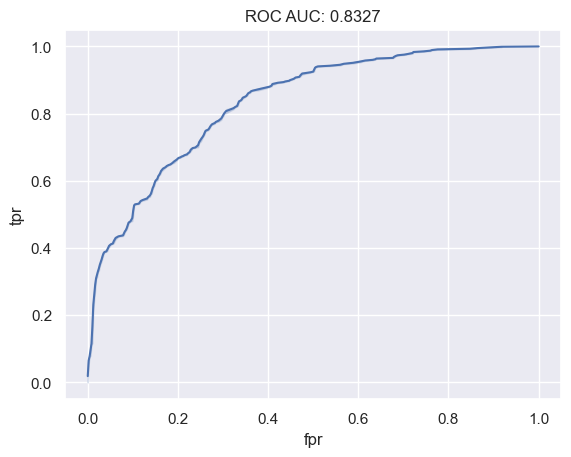

In [34]:
fpr, tpr, thresholds = roc_curve(df['y'], df['prediction'])

plot_df = pd.DataFrame({
    "fpr": fpr,
    "tpr": tpr,
    "thresholds": thresholds
})

fig, ax = plt.subplots()
sns.lineplot(data=plot_df, x='fpr', y='tpr', ax=ax)

ax.set_title(f"ROC AUC: {roc_auc_score(df['y'], df['prediction']):.4f}")

# ROC AUC - Kfolds

In [70]:
results = []
for j in range(5, 100, 5):
    kf = KFold(n_splits=j, shuffle=True, random_state=42)

    aucs = []
    for train_index, test_index in kf.split(df.index):
        tmp_df = df.iloc[test_index]
        aucs.append(roc_auc_score(tmp_df['y'], tmp_df['prediction']))

    results.append((j, aucs))

In [83]:
stat_results = []
for i in results:
    stat_results.append((i[0], np.mean(i[1]), np.std(i[1])))

plot_df = pd.DataFrame(stat_results, columns=['folds', 'roc_auc__mean', 'roc_auc__stddev'])
plot_df = plot_df.set_index("folds")
plot_df

,roc_auc__mean,roc_auc__stddev
folds,,
5,0.833050,0.015777
10,0.831985,0.037451
15,0.832405,0.046458
20,0.831464,0.049976
25,0.833164,0.061670
30,0.830079,0.069028
35,0.831077,0.078047
40,0.834280,0.081110
45,0.831067,0.087742


# Metric not grouped - Kfolds

In [84]:
from sklearn.metrics import log_loss

log_loss(df['y'], df['prediction'])

0.5844218345793978

In [87]:
results = []
for j in range(5, 100, 5):
    kf = KFold(n_splits=j, shuffle=True, random_state=42)

    metrics = []
    for train_index, test_index in kf.split(df.index):
        tmp_df = df.iloc[test_index]
        metrics.append(log_loss(tmp_df['y'], tmp_df['prediction']))

    results.append((j, metrics))

In [88]:
stat_results = []
for i in results:
    stat_results.append((i[0], np.mean(i[1]), np.std(i[1])))

plot_df = pd.DataFrame(stat_results, columns=['folds', 'log_loss__mean', 'log_loss__stddev'])
plot_df = plot_df.set_index("folds")
plot_df

,log_loss__mean,log_loss__stddev
folds,,
5,0.584422,0.042083
10,0.584422,0.079649
15,0.584861,0.137573
20,0.584422,0.128733
25,0.584422,0.160427
30,0.584903,0.181211
35,0.585049,0.179807
40,0.584422,0.203476
45,0.584905,0.191608
